<a href="https://colab.research.google.com/github/Satyam-Mittal2527/Deep_Learning_Concepts/blob/main/DogVsCatDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d tongpython/cat-and-dog

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
100% 218M/218M [00:01<00:00, 170MB/s]



In [ ]:
!unzip cat-and-dog.zip

Streaming output truncated to the last 5000 lines.
  inflating: training_set/training_set/cats/cat.3704.jpg  
  inflating: training_set/training_set/cats/cat.3705.jpg  
  inflating: training_set/training_set/cats/cat.3706.jpg  
  inflating: training_set/training_set/cats/cat.3707.jpg  
  inflating: training_set/training_set/cats/cat.3708.jpg  
  inflating: training_set/training_set/cats/cat.3709.jpg  
  inflating: training_set/training_set/cats/cat.371.jpg  
  inflating: training_set/training_set/cats/cat.3710.jpg  
  inflating: training_set/training_set/cats/cat.3711.jpg  
  inflating: training_set/training_set/cats/cat.3712.jpg  
  inflating: training_set/training_set/cats/cat.3713.jpg  
  inflating: training_set/training_set/cats/cat.3714.jpg  
  inflating: training_set/training_set/cats/cat.3715.jpg  
  inflating: training_set/training_set/cats/cat.3716.jpg  
  inflating: training_set/training_set/cats/cat.3717.jpg  
  inflating: training_set/training_set/cats/cat.3718.jpg  
  infl

In [ ]:
ls

cat-and-dog.zip  kaggle.json  sample_data/  test_set/  training_set/


In [ ]:
import os

In [ ]:
train_path = "/content/training_set/training_set"
test_path = "/content/test_set/test_set"

###TEST DATASET

In [ ]:
for files in os.listdir(test_path):
  test_image_count = 0
  path = f"{test_path}/{files}"
  for images in os.listdir(path):
    if(images[:2]==files[:2]):
      test_image_count +=1
  print(f"Number of images in Test {files} is:{test_image_count}")

Number of images in Test dogs is:1012
Number of images in Test cats is:1011


###TRAIN DATASET

In [ ]:
for files in os.listdir(train_path):
  train_image_count = 0
  img_path = f"{train_path}/{files}"
  for images in os.listdir(img_path):
    if(images[:2]==files[:2]):
      train_image_count+=1
  print(f"Number of Images in train {files} is : {train_image_count}")

Number of Images in train dogs is : 4005
Number of Images in train cats is : 4000


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,BatchNormalization,Dropout

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
batch_size=32

train_datagen = ImageDataGenerator(
    rescale = 1./255,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True
)
test_datagen = ImageDataGenerator(
    rescale = 1./255
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size = (256,256),
    batch_size = batch_size,
    class_mode = 'binary'
)

validation_generator = test_datagen.flow_from_directory(
    test_path,
    target_size = (256,256),
    batch_size = batch_size,
    class_mode = 'binary'
)

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


In [ ]:
# Train_Dataset = keras.utils.image_dataset_from_directory(
#     directory = train_path,
#     labels = 'inferred',
#     label_mode = 'int',
#     batch_size = 32,
#     image_size = (256,256)
# )
# Validation_Dataset = keras.utils.image_dataset_from_directory(
#     directory = test_path,
#     labels = 'inferred',
#     label_mode = 'int',
#     batch_size = 32,
#     image_size = (256,256)
# )

###Normalize

In [ ]:
# def process(image,label):
#   image = tf.cast(image/255,tf.float32)
#   return image,label
# Train_Dataset = Train_Dataset.map(process)
# Validation_Dataset = Validation_Dataset.map(process)

###Create CNN Model

In [ ]:
model = Sequential()

model.add(Conv2D(32,kernel_size = (3,3), padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides=2, padding='valid'))

model.add(Conv2D(64,kernel_size = (3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides=2, padding='valid'))

model.add(Conv2D(128,kernel_size = (3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# history=model.fit(Train_Dataset, epochs=10, validation_data=Validation_Dataset)
history=model.fit(train_generator, epochs=10, validation_data=validation_generator)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 153s 558ms/step - accuracy: 0.5485 - loss: 1.9086 - val_accuracy: 0.5002 - val_loss: 4.0927
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 131s 524ms/step - accuracy: 0.5890 - loss: 0.6998 - val_accuracy: 0.5215 - val_loss: 1.3935
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 131s 521ms/step - accuracy: 0.5970 - loss: 0.6663 - val_accuracy: 0.5976 - val_loss: 0.6349
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 131s 522ms/step - accuracy: 0.6354 - loss: 0.6437 - val_accuracy: 0.5274 - val_loss: 0.6881
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 130s 519ms/step - accuracy: 0.6493 - loss: 0.6252 - val_accuracy: 0.6441 - val_loss: 0.6313
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 129s 513ms/step - accuracy: 0.6858 - loss: 0.5813 - val_accuracy: 0.6500 - val_loss: 0.6622
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 129s 514ms/step - accuracy: 0.7066 - loss: 0.5561 - val_accuracy: 0.6174 - val_loss: 0.6340
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 130s 516ms/step - accuracy: 0.6993 -

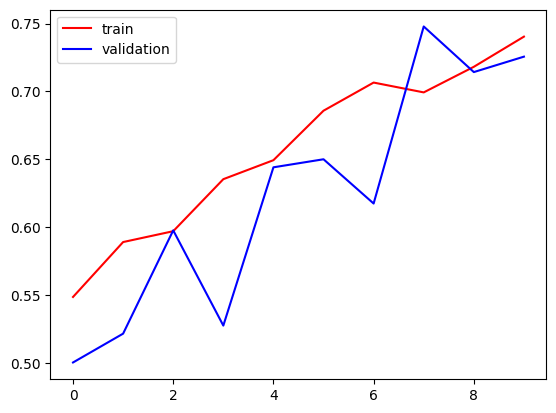

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
import cv2

In [ ]:
test_image = cv2.imread("/content/test_set/test_set/dogs/dog.4003.jpg")

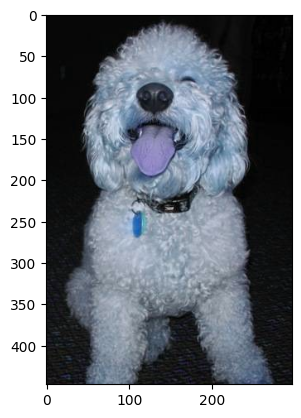

In [ ]:
plt.imshow(test_image)

In [ ]:
test_image.shape

(447, 297, 3)

In [ ]:
test_image = cv2.resize(test_image,(256,256))

In [ ]:
test_input = test_image.reshape((1,256,256,3))

In [ ]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[0.47211918]], dtype=float32)